# Hybrid State-Space Attention (HSA) - Honest Benchmark
**Run this notebook yourself. No cherry-picking.**

Author: Vladimir0-1 | License: MIT

In [14]:
!pip install torch transformers numpy matplotlib tqdm datasets -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer

# Clone repository
!rm -rf /content/Hybrid-State-Space-Attention-HSA-
!git clone https://github.com/Vladimir0-1/Hybrid-State-Space-Attention-HSA-.git
%cd /content/Hybrid-State-Space-Attention-HSA-

from hsa import HybridStateSpaceAttention

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
fatal: could not create work tree dir 'Hybrid-State-Space-Attention-HSA-': No such file or directory
[Errno 2] No such file or directory: '/content/Hybrid-State-Space-Attention-HSA-'
/content/Hybrid-State-Space-Attention-HSA-


In [15]:
class StandardAttention(nn.Module):
    def __init__(self, hidden_size, num_heads, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(hidden_size, hidden_size * 3)
        self.proj = nn.Linear(hidden_size, hidden_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.dropout(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.proj(x)


class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_heads, num_layers, attention_class, **attn_kwargs):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, hidden_size)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'norm1': nn.LayerNorm(hidden_size),
                'attn': attention_class(hidden_size, num_heads, **attn_kwargs),
                'norm2': nn.LayerNorm(hidden_size),
                'ffn': nn.Sequential(
                    nn.Linear(hidden_size, hidden_size * 4),
                    nn.GELU(),
                    nn.Linear(hidden_size * 4, hidden_size)
                )
            }) for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(hidden_size)
        self.lm_head = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = self.embed(x)
        for layer in self.layers:
            residual = x
            x = layer['norm1'](x)
            x = layer['attn'](x)
            x = residual + x
            residual = x
            x = layer['norm2'](x)
            x = layer['ffn'](x)
            x = residual + x
        x = self.norm(x)
        return self.lm_head(x)

Running on: cuda


Benchmarking: 100%|██████████| 6/6 [00:11<00:00,  1.88s/it]



 Raw Benchmark Data:
 Seq Len | Standard (ms) |   HSA (ms) | Speedup | Std Mem (MB) | HSA Mem (MB)
----------------------------------------------------------------------
     128 |       8.35 ±0.2 |     8.57 ±0.7 |    1.0x |      3429.2 |      3466.1
     256 |       8.15 ±0.1 |     8.21 ±0.2 |    1.0x |      3495.2 |      3483.4
     512 |      10.88 ±0.1 |     9.92 ±0.4 |    1.1x |      3588.6 |      3543.6
    1024 |      27.76 ±0.3 |    24.49 ±0.4 |    1.1x |      3899.2 |      3756.2
    2048 |      83.92 ±0.5 |    36.97 ±0.8 |    2.3x |      5008.6 |      3903.4
    4096 |     285.21 ±1.6 |    72.35 ±0.5 |    3.9x |      9322.9 |      4337.8


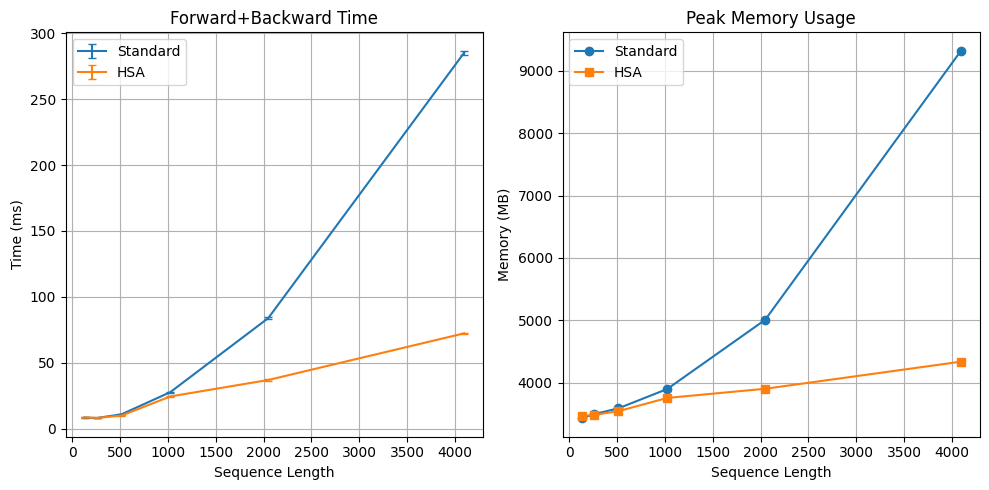

In [17]:
def benchmark_speed_memory(model, seq_len, device='cuda', num_iters=15):
    model = model.to(device)
    model.train()
    x = torch.randint(0, 1000, (1, seq_len)).to(device)

    for _ in range(3):
        out = model(x)
        loss = out.mean()
        loss.backward()
        model.zero_grad()

    if device == 'cuda':
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    times = []
    for _ in range(num_iters):
        start = time.time()
        out = model(x)
        loss = out.mean()
        loss.backward()
        model.zero_grad()
        if device == 'cuda':
            torch.cuda.synchronize()
        times.append(time.time() - start)

    peak_mem = torch.cuda.max_memory_allocated() / 1024**2 if device == 'cuda' else None

    return {
        'mean_time_ms': np.mean(times) * 1000,
        'std_time_ms': np.std(times) * 1000,
        'peak_memory_mb': peak_mem
    }


seq_lengths = [128, 256, 512, 1024, 2048, 4096]
configs = {
    'hidden_size': 256,
    'num_heads': 8,
    'num_layers': 4,
    'vocab_size': 10000
}

results = {'standard': [], 'hsa': []}
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Running on: {device}")

for seq_len in tqdm(seq_lengths, desc="Benchmarking"):
    model_std = TinyTransformer(**configs, attention_class=StandardAttention, dropout=0.1)
    std_res = benchmark_speed_memory(model_std, seq_len, device)

    model_hsa = TinyTransformer(**configs, attention_class=HybridStateSpaceAttention, window_size=512, num_global_tokens=64)
    hsa_res = benchmark_speed_memory(model_hsa, seq_len, device)

    results['standard'].append(std_res)
    results['hsa'].append(hsa_res)

print("\n Raw Benchmark Data:")
print("="*70)
print(f"{'Seq Len':>8} | {'Standard (ms)':>12} | {'HSA (ms)':>10} | {'Speedup':>7} | {'Std Mem (MB)':>11} | {'HSA Mem (MB)':>11}")
print("-"*70)
for i, seq in enumerate(seq_lengths):
    std_mem_str = f"{results['standard'][i]['peak_memory_mb']:.1f}" if results['standard'][i]['peak_memory_mb'] else "N/A"
    hsa_mem_str = f"{results['hsa'][i]['peak_memory_mb']:.1f}" if results['hsa'][i]['peak_memory_mb'] else "N/A"
    speedup = results['standard'][i]['mean_time_ms'] / results['hsa'][i]['mean_time_ms']
    print(f"{seq:8d} | {results['standard'][i]['mean_time_ms']:10.2f} ±{results['standard'][i]['std_time_ms']:.1f} | {results['hsa'][i]['mean_time_ms']:8.2f} ±{results['hsa'][i]['std_time_ms']:.1f} | {speedup:6.1f}x | {std_mem_str:>11} | {hsa_mem_str:>11}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.errorbar(seq_lengths, [r['mean_time_ms'] for r in results['standard']], yerr=[r['std_time_ms'] for r in results['standard']], label='Standard', capsize=3)
plt.errorbar(seq_lengths, [r['mean_time_ms'] for r in results['hsa']], yerr=[r['std_time_ms'] for r in results['hsa']], label='HSA', capsize=3)
plt.xlabel('Sequence Length')
plt.ylabel('Time (ms)')
plt.title('Forward+Backward Time')
plt.legend()
plt.grid(True)

if device == 'cuda':
    plt.subplot(1, 2, 2)
    plt.plot(seq_lengths, [r['peak_memory_mb'] for r in results['standard']], 'o-', label='Standard')
    plt.plot(seq_lengths, [r['peak_memory_mb'] for r in results['hsa']], 's-', label='HSA')
    plt.xlabel('Sequence Length')
    plt.ylabel('Memory (MB)')
    plt.title('Peak Memory Usage')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.savefig('/tmp/honest_benchmark.png', dpi=150)
plt.show()

In [ ]:
import warnings
import logging
import torch
import torch.nn.functional as F
from datasets import load_dataset
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    for batch in dataloader:
        if isinstance(batch, dict):
            x = batch['input_ids'].to(device)
        else:
            x = batch.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), x.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

print("Loading WikiText-2 dataset...")
dataset = load_dataset('wikitext', 'wikitext-2-raw-v1', split='train')
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token else '[PAD]'

configs['vocab_size'] = len(tokenizer)
print(f"Tokenizer vocab size: {configs['vocab_size']}")

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=128)

print("Tokenizing dataset...")
dataset = dataset.map(tokenize, batched=True, remove_columns=['text'])
dataset.set_format(type='torch', columns=['input_ids'])
dataloader = torch.utils.data.DataLoader(dataset, batch_size=8, shuffle=True)

print("\nTraining Standard Model (3 epochs)...")
model_std = TinyTransformer(**configs, attention_class=StandardAttention).to(device)
opt_std = torch.optim.Adam(model_std.parameters(), lr=1e-3)
losses_std = []
for epoch in range(3):
    loss = train_one_epoch(model_std, dataloader, opt_std, device)
    losses_std.append(loss)
    print(f"Epoch {epoch+1}: Loss = {loss:.4f}")

print("\nTraining HSA Model (3 epochs)...")
model_hsa = TinyTransformer(**configs, attention_class=HybridStateSpaceAttention, window_size=512, num_global_tokens=64).to(device)
opt_hsa = torch.optim.Adam(model_hsa.parameters(), lr=1e-3)
losses_hsa = []
for epoch in range(3):
    loss = train_one_epoch(model_hsa, dataloader, opt_hsa, device)
    losses_hsa.append(loss)
    print(f"Epoch {epoch+1}: Loss = {loss:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, 4), losses_std, 'o-', label='Standard')
plt.plot(range(1, 4), losses_hsa, 's-', label='HSA')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Convergence on WikiText-2')
plt.legend()
plt.grid(True)
plt.savefig('/tmp/convergence.png', dpi=150)
plt.show()

print(f"\nFinal Loss: Standard {losses_std[-1]:.4f} | HSA {losses_hsa[-1]:.4f}")

Loading WikiText-2 dataset...
Tokenizer vocab size: 30522
Tokenizing dataset...

Training Standard Model (3 epochs)...
Epoch 1: Loss = 0.1453


In [ ]:
# Long context test (8192 tokens)
long_seq = 8192
if device == 'cuda' and torch.cuda.get_device_properties(0).total_memory > 12e9:
    print(f"Testing with sequence length {long_seq}...")

    try:
        model_std_long = TinyTransformer(**configs, attention_class=StandardAttention).to(device)
        x = torch.randint(0, 1000, (1, long_seq)).to(device)
        start = time.time()
        out = model_std_long(x)
        std_time = time.time() - start
        print(f"Standard: {std_time:.2f}s")
    except RuntimeError as e:
        print(f"Standard: OOM - {str(e)[:50]}")
        std_time = None

    model_hsa_long = TinyTransformer(**configs, attention_class=HybridStateSpaceAttention, window_size=1024, num_global_tokens=128).to(device)
    start = time.time()
    out = model_hsa_long(x)
    hsa_time = time.time() - start
    print(f"HSA: {hsa_time:.2f}s")

    if std_time:
        print(f"Speedup on {long_seq}: {std_time/hsa_time:.1f}x")
else:
    print(f"Skipping {long_seq} test (not enough GPU memory)")

print("\n Benchmark complete. Draw your own conclusions.")